In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import random

DATASET_PATH = r"Novi Dataset\patches_8000"
MODEL_SAVE_PATH = "SavedModels"
MODEL_NAME = "Patches8000_DGCNN.pth"
EPOCHS = 100
PATIENCE = 10
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
BATCH_SIZE = 4
K = 20

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"Training DGCNN on PATCHES on: {DEVICE}")
print(f"Dataset: {DATASET_PATH} | K: {K} | Seed: {SEED}")

Training DGCNN on PATCHES on: cuda
Dataset: Novi Dataset\patches_8000 | K: 20 | Seed: 42


In [2]:
class PatchDataset(Dataset):
    def __init__(self, file_paths, augment=False):
        self.file_paths = file_paths
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        data = np.load(file_path, allow_pickle=True).item()
        points = data['points'].astype(np.float32)
        colors = data['colors'].astype(np.float32)
        labels = data['labels'].astype(np.int64)
        if colors.max() > 1.0:
            colors = colors / 255.0

        if self.augment:
            angle = np.random.uniform(0, 2 * np.pi)
            cos_a, sin_a = np.cos(angle), np.sin(angle)
            rot = np.array([[cos_a, -sin_a, 0],
                            [sin_a,  cos_a, 0],
                            [0,      0,     1]], dtype=np.float32)
            points = points @ rot.T
            points += np.random.randn(*points.shape).astype(np.float32) * 0.005

        features = np.concatenate([points, colors], axis=1)   # (8000, 6)
        return (
            torch.tensor(features, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long),
            file_path
        )

In [3]:
def knn(x, k):
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx    = torch.sum(x ** 2, dim=1, keepdim=True)
    dist  = -xx - inner - xx.transpose(2, 1)
    idx   = dist.topk(k=k, dim=-1)[1]
    return idx

def get_graph_feature(x, k=20, idx=None):
    B, C, N = x.shape
    device  = x.device
    if idx is None:
        idx = knn(x, k=k)
    idx_base = torch.arange(0, B, device=device).view(-1, 1, 1) * N
    idx      = idx + idx_base
    idx      = idx.view(-1)
    x       = x.transpose(2, 1).contiguous()
    feature = x.view(B * N, -1)[idx, :]
    feature = feature.view(B, N, k, C)
    x       = x.view(B, N, 1, C).expand(B, N, k, C)
    feature = torch.cat((feature - x, x), dim=3)
    feature = feature.permute(0, 3, 1, 2)
    return feature

class EdgeConv(nn.Module):
    def __init__(self, in_channels, out_channels, k=20):
        super().__init__()
        self.k    = k
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels * 2, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        feat = get_graph_feature(x, k=self.k)
        feat = self.conv(feat)
        feat = feat.max(dim=-1)[0]
        return feat

class DGCNNRGBSegmentation(nn.Module):
    def __init__(self, num_classes=4, k=20):
        super().__init__()
        self.k = k
        self.ec1 = EdgeConv(6,   64,  k=k)
        self.ec2 = EdgeConv(64,  64,  k=k)
        self.ec3 = EdgeConv(64,  64,  k=k)
        self.ec4 = EdgeConv(64,  128, k=k)
        self.conv1 = nn.Sequential(
            nn.Conv1d(64 + 64 + 64 + 128, 1024, 1, bias=False),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.seg_conv1 = nn.Sequential(
            nn.Conv1d(1024 + 64 + 64 + 64 + 128, 512, 1, bias=False),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2, inplace=True))
        self.seg_conv2 = nn.Sequential(
            nn.Conv1d(512, 256, 1, bias=False),
            nn.BatchNorm1d(256), nn.LeakyReLU(0.2, inplace=True))
        self.drop      = nn.Dropout(0.5)
        self.seg_conv3 = nn.Conv1d(256, num_classes, 1)

    def forward(self, xyzrgb):
        B, N, _ = xyzrgb.shape
        x = xyzrgb.permute(0, 2, 1)
        x1 = self.ec1(x)
        x2 = self.ec2(x1)
        x3 = self.ec3(x2)
        x4 = self.ec4(x3)
        x_cat    = torch.cat([x1, x2, x3, x4], dim=1)
        x_global = self.conv1(x_cat)
        x_global = x_global.max(dim=-1)[0].unsqueeze(-1).expand(B, 1024, N)
        x_out = torch.cat([x_global, x1, x2, x3, x4], dim=1)
        x_out = self.seg_conv1(x_out)
        x_out = self.seg_conv2(x_out)
        x_out = self.drop(x_out)
        x_out = self.seg_conv3(x_out)
        return x_out

In [4]:
patch_pattern = os.path.join(DATASET_PATH, "tree_*", "*", "*.npy")
all_patch_files = glob.glob(patch_pattern)
print(f"Ukupno patcheva: {len(all_patch_files)}")

def get_tree_name(fp):
    return fp.split(os.sep)[-3]

unique_trees = sorted(list(set(get_tree_name(f) for f in all_patch_files)))
train_trees, test_trees = train_test_split(unique_trees, test_size=0.15, random_state=42)
train_trees, val_trees  = train_test_split(train_trees,  test_size=0.18, random_state=42)
train_trees, val_trees, test_trees = set(train_trees), set(val_trees), set(test_trees)

train_paths = [f for f in all_patch_files if get_tree_name(f) in train_trees]
val_paths   = [f for f in all_patch_files if get_tree_name(f) in val_trees]
test_paths  = [f for f in all_patch_files if get_tree_name(f) in test_trees]

train_dataset = PatchDataset(train_paths, augment=True)
val_dataset   = PatchDataset(val_paths,   augment=False)
test_dataset  = PatchDataset(test_paths,  augment=False)

generator_treninga = torch.Generator()
generator_treninga.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, generator=generator_treninga)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=0)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Ukupno patcheva: 8107
Train: 5460 | Val: 1491 | Test: 1156


Ucestalost klasa: {0: 4842487, 1: 26627415, 2: 5499697, 3: 6710401}
Auto alpha: ['2.255', '0.410', '1.986', '1.627']


Epoch 1/100: 100%|██████████| 1365/1365 [29:09<00:00,  1.28s/it, Loss=0.2839]


Epoch [1/100] -> Loss: 0.5240, Train Acc: 0.6002, Val Acc: 0.7400 | Time: 1857.2s
--- Best model saved (Val Acc: 0.7400) ---


Epoch 2/100: 100%|██████████| 1365/1365 [27:21<00:00,  1.20s/it, Loss=0.3916]


Epoch [2/100] -> Loss: 0.4272, Train Acc: 0.7066, Val Acc: 0.7917 | Time: 1738.6s
--- Best model saved (Val Acc: 0.7917) ---


...

Epoch [24/100] -> Loss: 0.2715, Train Acc: 0.8402, Val Acc: 0.8224 | Time: 1721.2s
--- No improvement: 8/10 ---


Epoch 25/100: 100%|██████████| 1365/1365 [27:03<00:00,  1.19s/it, Loss=0.1747]


Epoch [25/100] -> Loss: 0.2663, Train Acc: 0.8440, Val Acc: 0.8046 | Time: 1720.4s
--- No improvement: 9/10 ---


Epoch 26/100: 100%|██████████| 1365/1365 [27:19<00:00,  1.20s/it, Loss=0.2205]


Epoch [26/100] -> Loss: 0.2771, Train Acc: 0.8392, Val Acc: 0.7577 | Time: 1745.4s
--- No improvement: 10/10 ---
Early stopping triggered after 26 epochs. Best Val Acc: 0.8639

Ukupno vrijeme treninga: 12:31:30


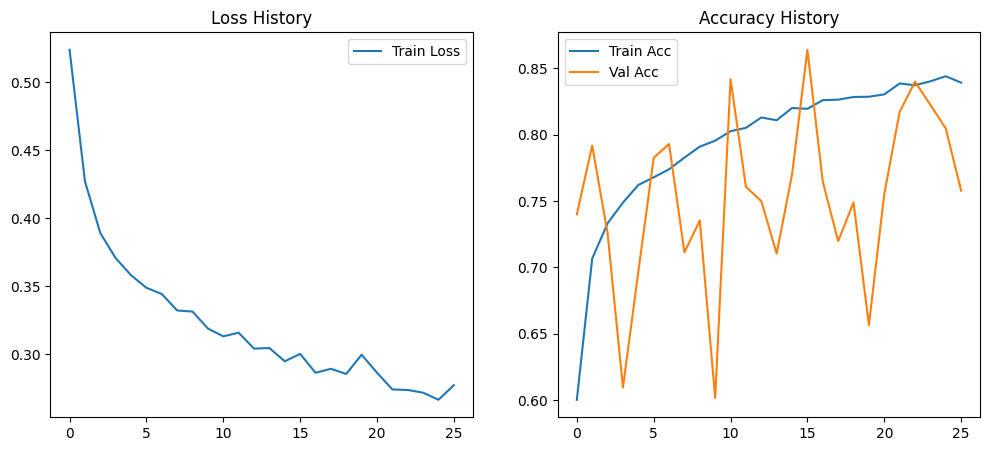

In [5]:
set_seed(SEED)

model = DGCNNRGBSegmentation(num_classes=4, k=K).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor([float(alpha)] * NUM_CLASSES)
        else:
            self.alpha = torch.tensor(alpha, dtype=torch.float32)
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            at = alpha[targets]
            focal_loss = at * (1 - pt) ** self.gamma * ce_loss
        else:
            focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax_flat(probas, labels, classes='present'):
    if probas.numel() == 0:
        return probas * 0.0
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    for c in class_to_sum:
        fg = (labels == c).float()
        if classes == 'present' and fg.sum() == 0:
            continue
        class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    if len(losses) == 0:
        return probas.sum() * 0.0
    return torch.stack(losses).mean()

class LovaszSoftmaxLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, inputs, targets):
        probas = F.softmax(inputs, dim=1)
        B, C, N = probas.shape
        probas = probas.permute(0, 2, 1).reshape(-1, C)
        targets = targets.reshape(-1)
        return lovasz_softmax_flat(probas, targets)


from collections import Counter
brojac = Counter()
for fp in train_paths:
    d = np.load(fp, allow_pickle=True).item()
    lbls = np.array(d['labels'], dtype=np.int64)
    for c in range(NUM_CLASSES):
        brojac[c] += int(np.sum(lbls == c))

ukupno = sum(brojac.values())
alpha_auto = [ukupno / (NUM_CLASSES * brojac[c]) if brojac[c] > 0 else 0.0 for c in range(NUM_CLASSES)]
print("Ucestalost klasa:", dict(brojac))
print("Auto alpha:", [f"{a:.3f}" for a in alpha_auto])

criterion = FocalLoss(alpha=alpha_auto, gamma=2.0)
lovasz = LovaszSoftmaxLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, train_accs, val_accs = [], [], []
best_val_acc = 0.0
patience = PATIENCE
epochs_no_improve = 0

training_start = time.time()

try:
    for epoch in range(EPOCHS):
        epoch_start = time.time()
        model.train()
        epoch_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for features, labels, _ in pbar:
            features, labels = features.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(features)
            loss = 0.5 * criterion(outputs, labels) + 0.5 * lovasz(outputs, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.numel()

            pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct / total)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for features, labels, _ in val_loader:
                features, labels = features.to(DEVICE), labels.to(DEVICE)
                outputs = model(features)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()

        val_acc = val_correct / val_total if val_total > 0 else 0
        val_accs.append(val_acc)

        epoch_time = time.time() - epoch_start
        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, MODEL_NAME))
            print(f"--- Best model saved (Val Acc: {val_acc:.4f}) ---")
        else:
            epochs_no_improve += 1
            print(f"--- No improvement: {epochs_no_improve}/{patience} ---")
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs. Best Val Acc: {best_val_acc:.4f}")
                break

except KeyboardInterrupt:
    print(f"\nTrening prekinut. Najbolji Val Acc: {best_val_acc:.4f}")

total_time = time.time() - training_start
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nUkupno vrijeme treninga: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss History')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()

In [6]:
import open3d as o3d
import time
from collections import defaultdict

MODEL_PATH = os.path.join("SavedModels", "Patches8000_DGCNN.pth")
set_seed(SEED)
model = DGCNNRGBSegmentation(num_classes=4, k=K).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model loaded from: {MODEL_PATH}")

KLASE = {0: "deblo", 1: "grane", 2: "potpora", 3: "trava"}

def predict_logits(model, features, device):
    x = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(x)
    return out.squeeze(0).permute(1, 0).cpu().numpy()

oblaci = defaultdict(list)
for fp in test_paths:
    tree = fp.split(os.sep)[-3]
    cloud = fp.split(os.sep)[-2]
    oblaci[(tree, cloud)].append(fp)
print(f"Test oblaka: {len(oblaci)}")

conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
oblak_rezultati = []
inference_times = []

for (tree, cloud), patch_files in tqdm(oblaci.items(), desc="Rekonstrukcija po oblaku"):
    p0 = np.load(patch_files[0], allow_pickle=True).item()
    N = int(p0['n_original'])
    logit_sum = np.zeros((N, NUM_CLASSES), dtype=np.float64)
    logit_cnt = np.zeros(N, dtype=np.int64)
    prave_lbl = np.full(N, -1, dtype=np.int64)
    orig_points = np.zeros((N, 3), dtype=np.float64)
    orig_colors = np.zeros((N, 3), dtype=np.float64)

    t0 = time.perf_counter()
    for fp in patch_files:
        p = np.load(fp, allow_pickle=True).item()
        oi = p['orig_idx']
        points = p['points'].astype(np.float32)
        colors = p['colors'].astype(np.float32)
        cols_norm = colors / 255.0 if colors.max() > 1.0 else colors
        features = np.concatenate([points, cols_norm], axis=1)
        logits = predict_logits(model, features, DEVICE)
        logit_sum[oi] += logits
        logit_cnt[oi] += 1
        prave_lbl[oi] = p['labels']
        orig_points[oi] = points
        orig_colors[oi] = cols_norm
    inference_times.append(time.perf_counter() - t0)

    valid = logit_cnt > 0
    logit_avg = logit_sum[valid] / logit_cnt[valid, None]
    pred = np.argmax(logit_avg, axis=1)
    prave = prave_lbl[valid]
    for t, pr in zip(prave, pred):
        conf[t, pr] += 1

    ious = []
    for c in range(NUM_CLASSES):
        tp = np.sum((pred == c) & (prave == c))
        fp_ = np.sum((pred == c) & (prave != c))
        fn = np.sum((pred != c) & (prave == c))
        if np.sum(prave == c) > 0:
            ious.append(tp / (tp + fp_ + fn) if (tp + fp_ + fn) > 0 else 1.0)
    miou = np.mean(ious) if ious else 0.0

    oblak_rezultati.append({
        'tree': tree, 'cloud': cloud, 'miou': miou,
        'points': orig_points[valid], 'colors': orig_colors[valid],
        'labels': prave, 'preds': pred,
        'pokriveno': int(valid.sum()), 'ukupno': N
    })

total_points = conf.sum()
accuracy = np.trace(conf) / total_points if total_points > 0 else 0
per_class_iou, per_class_prec, per_class_rec = {}, {}, {}
for c in range(NUM_CLASSES):
    tp = conf[c, c]
    fp_ = conf[:, c].sum() - tp
    fn = conf[c, :].sum() - tp
    per_class_iou[c]  = tp / (tp + fp_ + fn) if (tp + fp_ + fn) > 0 else 0
    per_class_prec[c] = tp / (tp + fp_) if (tp + fp_) > 0 else 0
    per_class_rec[c]  = tp / (tp + fn) if (tp + fn) > 0 else 0
mean_iou = np.mean(list(per_class_iou.values()))

print("\n" + "="*50)
print("FINAL TEST METRICS: PATCHES DGCNN (rekonstruirano stablo)")
print("="*50)
print(f"Total Points: {total_points:,}")
print(f"Accuracy: {accuracy:.4f}")
print("-"*50)
for c in range(NUM_CLASSES):
    print(f"{KLASE[c]:<10} | IoU: {per_class_iou[c]:.4f} | Prec: {per_class_prec[c]:.4f} | Recall: {per_class_rec[c]:.4f}")
print("-"*50)
print(f"mIoU: {mean_iou:.4f}")
print("="*50)
print("\nConfusion [redak=stvarno, stupac=predvidjeno]:")
print(f"{'':<10}" + "".join(f"{KLASE[c]:<10}" for c in range(NUM_CLASSES)))
for c in range(NUM_CLASSES):
    print(f"{KLASE[c]:<10}" + "".join(f"{conf[c, p]:<10}" for p in range(NUM_CLASSES)))

svi_pokriveni = all(r['pokriveno'] == r['ukupno'] for r in oblak_rezultati)
print(f"\nRekonstrukcija egzaktna? {'DA' if svi_pokriveni else 'NE'}")
print(f"Prosjecno vrijeme po stablu: {np.mean(inference_times):.3f}s")
print("="*50)

PALETTE = {0: [0.0, 0.0, 1.0], 1: [0.0, 0.8, 0.0], 2: [1.0, 0.0, 0.0], 3: [0.6, 0.6, 0.6]}
def boji_po_klasi(labels):
    c = np.zeros((len(labels), 3))
    for k, col in PALETTE.items():
        c[labels == k] = col
    return c

oblak_rezultati.sort(key=lambda x: x['miou'])
worst, best = oblak_rezultati[0], oblak_rezultati[-1]
for tag, rez in [("WORST", worst), ("BEST", best)]:
    print(f"\n[{tag}] {rez['tree']}/{rez['cloud']} | mIoU: {rez['miou']:.4f}")
    pts = rez['points']
    for col, naslov in [(rez['colors'], "ORIGINAL RGB"),
                        (boji_po_klasi(rez['labels']), "LABELE"),
                        (boji_po_klasi(rez['preds']), "PREDIKCIJA")]:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.colors = o3d.utility.Vector3dVector(col)
        o3d.visualization.draw_geometries([pcd], window_name=f"{tag} {naslov} | mIoU {rez['miou']:.3f}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Model loaded from: SavedModels\Patches8000_DGCNN.pth
Test oblaka: 92


Rekonstrukcija po oblaku: 100%|██████████| 92/92 [01:31<00:00,  1.01it/s]



FINAL TEST METRICS: PATCHES DGCNN (rekonstruirano stablo)
Total Points: 8,865,711
Accuracy: 0.8619
--------------------------------------------------
deblo      | IoU: 0.3910 | Prec: 0.5267 | Recall: 0.6028
grane      | IoU: 0.8188 | Prec: 0.9467 | Recall: 0.8583
potpora    | IoU: 0.5723 | Prec: 0.5935 | Recall: 0.9412
trava      | IoU: 0.9930 | Prec: 0.9934 | Recall: 0.9996
--------------------------------------------------
mIoU: 0.6938

Confusion [redak=stvarno, stupac=predvidjeno]:
          deblo     grane     potpora   trava     
deblo     555562    257282    108157    615       
grane     481289    4952537   327593    8648      
potpora   17663     21442     636561    672       
trava     372       15        237       1497066   

Rekonstrukcija egzaktna? DA
Prosjecno vrijeme po stablu: 0.920s

[WORST] tree_1_V_0150/3 | mIoU: 0.4133

[BEST] tree_1_V_0178/3 | mIoU: 0.9914
